<a href="https://colab.research.google.com/github/cinth90/Datascience1/blob/main/Regresion_simple_con_LASSO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Ventajas de Lasso
* Realiza selección automática de variables, eliminando aquellas menos relevantes.
* Produce modelos más simples y fáciles de interpretar.
* Ayuda a controlar el sobreajuste, especialmente cuando hay muchas variables o cuando algunas están muy correlacionadas.
#Cuándo usar Lasso
* Cuando se sospecha que muchas variables no aportan información útil.
* Cuando se busca un modelo con menos variables y más fácil de interpretar.
* En casos con más características que observaciones, o cuando existe multicolinealidad entre las variables.


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
import warnings
warnings.simplefilter(action='ignore', category=Warning)

In [33]:
df=pd.read_csv("https://raw.githubusercontent.com/Andru-1987/77695_data_science_i_flex/refs/heads/main/07_clase/datasets/car_data.csv")

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [35]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [36]:
print(df.Fuel_Type.value_counts())
print(df.Seller_Type.value_counts())
print(df.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


#Codificación de etiquetas (Label Encoding)
 Dado que la mayoría de los algoritmos de Machine Learning requieren entradas numéricas, las categorías de texto se convierten en números.

In [37]:
#Codifico el tipo de combustible: Petrol=0, Diesel=1 y CNG=2
df.replace({'Fuel_Type':{'Petrol': 0 ,'Diesel': 1, 'CNG':2}},inplace=True)

#Codifico el seller: Dealer=0, Individual=1
df.replace({'Seller_Type':{'Dealer':0,'Individual':1}},inplace=True)

#Codifico la transmision: Manual=0, Automatico= 1
df.replace({'Transmission':{'Manual':0,'Automatic':1}},inplace=True)

In [38]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


#Conjunto de datos
Para el entrenamiento del modelo se separan las variables de entrada (x) y la variable de salida/objetivo (y).

In [41]:
X = df.drop(['Car_Name','Selling_Price'],axis=1) #datos que usaremos para hacer la predicción
#Se obtienen al eliminar las columnas Car_Name y Selling_Price (nombre del carro, generalmente no es útil para predecir el precio)
Y = df['Selling_Price'] #la variable que queremos predecir).

#Division del conjunto de datos
La función train_test_split de la librería scikit-learn divide el conjunto de datos ya preparado (X y Y) en cuatro subconjuntos esenciales para el entrenamiento y la evaluación de un modelo de Machine Learning.

**Datos de Entrenamiento (Train)**: Usados por el algoritmo para aprender los patrones y las relaciones entre las características (X) y la variable objetivo (Y).

* X_train: Características para el entrenamiento.

* Y_train: Precios objetivo para el entrenamiento.

**Datos de Prueba (Test)**: Usados para evaluar el rendimiento final del modelo una vez que ha terminado de aprender. El modelo realiza predicciones con X_test y se comparan con los valores reales Y_test.

* X_test: Características para la prueba.

* Y_test: Precios objetivo para la prueba.

In [42]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.1, random_state=2)
#test_size = 0.1:el 10% de los datos totales se destinarán al conjunto de prueba,
#y el 90% restante al conjunto de entrenamiento.

#random_state = 2: Es una "semilla" que asegura que la división de los datos
#sea la misma cada vez que ejecutas el código. Esto hace que tu experimento sea reproducible.

#Modelo de Mínimos Cuadrados Ordinarios (OLS) utilizando la librería statsmodels en Python.
Este es un paso fundamental para realizar una regresión lineal de los datos.

En estadística, un modelo de regresión lineal necesita un término constante, conocido como el intercepto.

Función sm.add_constant(): Esta función agrega una columna de unos (1s) a tu matriz de características de entrenamiento (X_train). Cuando el modelo se ajusta, el coeficiente asociado a esta columna representa el valor esperado de Y cuando todas las demás variables (X) son cero.

In [44]:
import statsmodels.api as sm

X_intercepto = sm.add_constant(X_train)  # Intercepto + variables numéricas
model_sm = sm.OLS(Y_train.astype(float), X_intercepto).fit()
# Asegurar que 'y' también sea float


El modelo de regresión lineal ha sido entrenado sobre el 90% de los datos, y el siguiente paso lógico es examinar los resultados

In [45]:
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:          Selling_Price   R-squared:                       0.880
Model:                            OLS   Adj. R-squared:                  0.877
Method:                 Least Squares   F-statistic:                     274.3
Date:                Mon, 29 Sep 2025   Prob (F-statistic):          1.11e-116
Time:                        13:51:18   Log-Likelihood:                -542.61
No. Observations:                 270   AIC:                             1101.
Df Residuals:                     262   BIC:                             1130.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          -823.0160     92.711     -8.877

1. Interpretación Global del Modelo (Ajuste)

* R-squared	0.880	El modelo explica el 88.0% de la variabilidad en el Selling_Price (Precio de Venta). Es un ajuste muy fuerte.
* Adj.R-squared	0.877	Similar al R2, ajustado por el número de variables. Sigue siendo muy alto.
* F-statistic 274.3	Muestra que el modelo en su conjunto es estadísticamente significativo para predecir el Selling_Price.
* Prob (F-statistic)	1.11e
−116  (muy cercano a 0)	La probabilidad de que este ajuste haya ocurrido por casualidad es esencialmente nula.

**Conclusión del Ajuste**: El modelo de regresión lineal es un excelente predictor del precio de venta del coche.

2. Análisis de Coeficientes e Impacto de Variables
Los coeficientes (coef) indican el cambio en el Selling_Price por cada aumento de una unidad en la variable predictora, manteniendo las demás variables constantes.

| Variable | Coeficiente (coef) | P>∣t∣ | Interpretación |
| :---: | :---: | :---: | :--- |
| const | −823.0160 | 0.000 | Valor del precio cuando todas las variables predictoras (incluyendo Year como año base 0) son cero. |
| Year | 0.4094 | 0.000 | Por cada año adicional de antigüedad, el precio de venta aumenta en 0.4094 unidades monetarias (esto es contraintuitivo, pero se debe a que Year probablemente no está centrado o se refiere al año de fabricación, lo que indica que coches más nuevos son más caros). |
| Present_Price | 0.4387 | 0.000 | Por cada unidad que aumenta el Present_Price (Precio Actual/Ex-Showroom), el Selling_Price aumenta en 0.4387 unidades. Es el predictor más fuerte (por tener el valor t más alto). |
| Kms_Driven | −6.731e
−06
  | 0.049 | Por cada kilómetro adicional recorrido, el precio de venta disminuye muy ligeramente. Es significativo. |
| Fuel_Type | 1.7631 | 0.000 | Los tipos de combustible más altos en la codificación (Diesel=1,CNG=2) tienden a tener un precio de venta mayor que el tipo base (Petrol=0). (Diesel es más caro que Petrol, CNG es el más caro). |
| Seller_Type | −1.0042 | 0.000 | Un tipo de vendedor más alto en la codificación (Individual=1) resulta en un precio de venta menor en 1.0042 unidades que el tipo base (Dealer=0). |
| Transmission | 1.5074 | 0.000 | Un coche con Transmisión Automática (Automatic=1) tiene un precio de venta mayor en 1.5074 unidades que uno Manual (Manual=0). |
| Owner | −0.8741 | 0.052 | Técnicamente no es significativo al nivel α=0.05 (su valor P>∣t∣ es 0.052). Sin embargo, está muy cerca del umbral, lo que sugiere que cada propietario adicional reduce el precio de venta. |



3. Diagnóstico del Modelo (Notas)
Condición Numérica (Cond. No. 4.61e+07):

Advertencia: El alto número de condición indica que puede haber multicolinealidad fuerte (alta correlación entre variables predictoras) o problemas numéricos.

Implicación: La multicolinealidad hace que los coeficientes individuales (coef) sean inestables (sensibles a pequeños cambios en los datos), aunque el poder predictivo general (R
2
 ) sigue siendo alto. La variable Year o Present_Price son candidatos probables para esto.

Pruebas de Normalidad y Homocedasticidad:

Omnibus / Jarque-Bera (Prob ≈0.000): Indica que los residuos (errores) no están distribuidos normalmente.

Kurtosis (9.609) y Skew (1.012): Confirman que la distribución de los residuos es asimétrica y tiene colas pesadas (alta curtosis).

Sugerencias:

El modelo es muy predictivo, pero los diagnósticos sugieren que podría haber violaciones de los supuestos del OLS.

Se recomienda centrar la variable Year (restarle un valor base) o aplicar técnicas para mitigar la multicolinealidad, como la Regresión Ridge, para obtener coeficientes más estables.

Una transformación logarítmica de la variable Selling_Price y Present_Price podría mejorar la normalidad de los residuos.

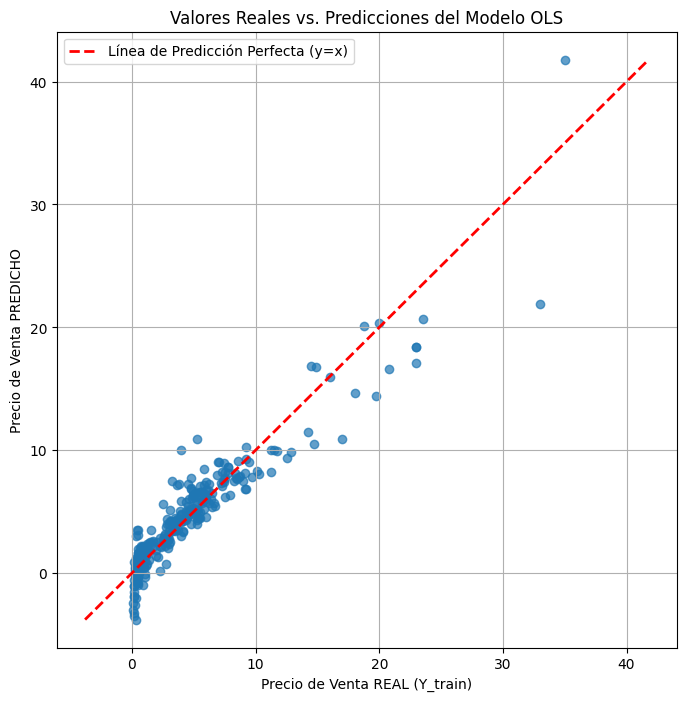

In [46]:
import numpy as np # Necesario para la línea de 45 grados

# 1. Obtener las Predicciones
# Asegúrate de usar X_intercepto (con la columna 'const')
predicciones = model_sm.predict(X_intercepto)

# 2. Configurar el Gráfico
plt.figure(figsize=(8, 8))

# Gráfico de dispersión de Predicciones vs. Valores Reales
plt.scatter(Y_train, predicciones, alpha=0.7)

# Línea de referencia y=x (diagonal perfecta de 45 grados)
# Si los puntos caen cerca de esta línea, el modelo es preciso.
max_val = max(Y_train.max(), predicciones.max())
min_val = min(Y_train.min(), predicciones.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2,
         label='Línea de Predicción Perfecta (y=x)')

plt.title('Valores Reales vs. Predicciones del Modelo OLS')
plt.xlabel('Precio de Venta REAL (Y_train)')
plt.ylabel('Precio de Venta PREDICHO')
plt.legend()
plt.grid(True)
plt.show()